In [2]:
data_dir = "/scratch/mjehangir/manuscript_figures/manuscript_data/"
setwd(data_dir)

In [41]:
library(karyoploteR)

In [42]:
library(dplyr)
library(tidyr)
library(ggplot2)

In [43]:
cytobands <- read.table("/home/mjehangir/chm13_chrs_arms/cytoBandMapped.bed", header = FALSE, sep = "\t",
                        col.names = c("chr", "start", "end", "name", "gieStain"))
head(cytobands)

,chr,start,end,name,gieStain
,<chr>,<int>,<int>,<chr>,<chr>
1,chr1,0,1735965,p36.33,gneg
2,chr1,1735965,4816989,p36.32,gpos25
3,chr1,4816989,6629068,p36.31,gneg
4,chr1,6629068,8634052,p36.23,gpos25
5,chr1,8634052,12044143,p36.22,gneg
6,chr1,12044143,15341266,p36.21,gpos50


In [6]:
library(dplyr)

custom_genome <- cytobands %>%
  group_by(chr) %>%
  summarize(start = 0, end = max(end)) %>%
  ungroup()


In [7]:
library(GenomicRanges)

custom_genome_gr <- makeGRangesFromDataFrame(custom_genome)


No predefined canonical chromosomes found for the requested genome. Applying a heuristic chromosome filtering.

To get the unfiltered genome, please set chromosomes="all" in the plotKaryotype call



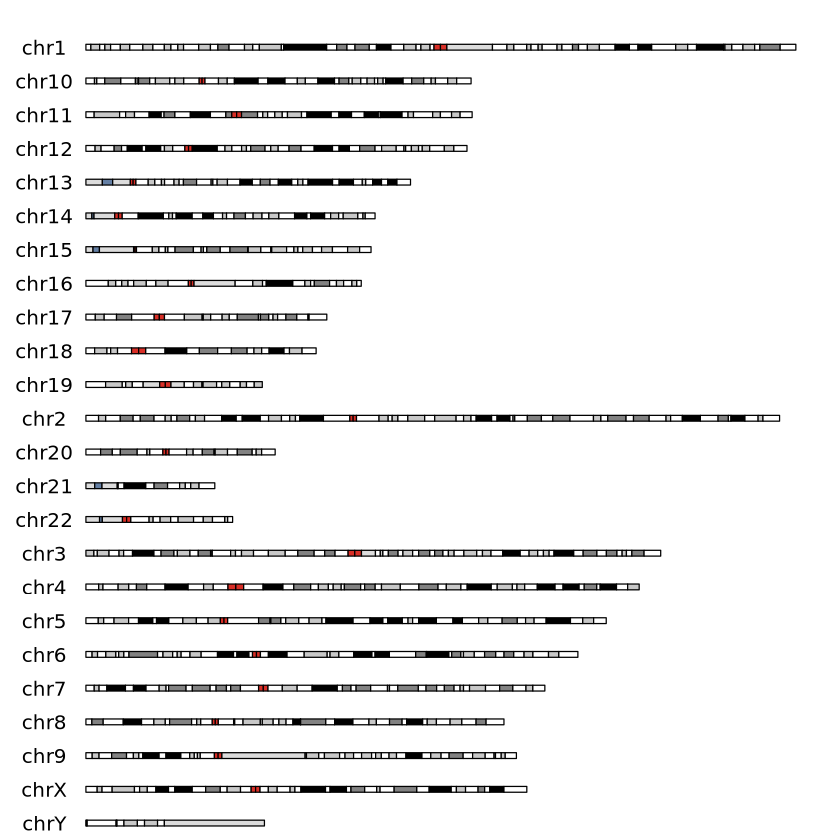

In [8]:
library(karyoploteR)

kp <- plotKaryotype(genome = custom_genome_gr, cytobands = cytobands)


In [9]:
df_cnv <- read.delim("Mean_normalized_v3_tab.seg", header = TRUE)
head(df_cnv)

,ID,chrom,loc.start,loc.end,num.mark,seg.mean,Arm
,<chr>,<int>,<int>,<int>,<int>,<dbl>,<lgl>
1,2436A,1,200151,28021140,130,0.0534,NA
2,2436A,1,142707663,142907814,2,1.3533,NA
3,2436A,10,88303635,101719380,68,0.0066,NA
4,2436A,10,101919615,104722905,15,-0.1040,NA
5,2436A,10,104923140,112932540,41,-0.0198,NA
6,2436A,10,113132775,120741705,39,-0.4022,NA


In [10]:
# View the data
df_cnv <- df_cnv %>% select(-Arm)
df_cnv$chrom <- paste0("chr", df_cnv$chrom)

head(df_cnv)

,ID,chrom,loc.start,loc.end,num.mark,seg.mean
,<chr>,<chr>,<int>,<int>,<int>,<dbl>
1,2436A,chr1,200151,28021140,130,0.0534
2,2436A,chr1,142707663,142907814,2,1.3533
3,2436A,chr10,88303635,101719380,68,0.0066
4,2436A,chr10,101919615,104722905,15,-0.1040
5,2436A,chr10,104923140,112932540,41,-0.0198
6,2436A,chr10,113132775,120741705,39,-0.4022


In [11]:
# Step 3: Assign Gain, Loss, or Neutral based on seg.mean

df_cnv$Gain_Loss <- case_when(
  df_cnv$seg.mean < -0.5 ~ "Loss", ### assuming negative values as loss 
  df_cnv$seg.mean > 0.5 ~ "Gain", ### assuming positive values as gain

  TRUE ~ "Neutral"
)
head(df_cnv)

,ID,chrom,loc.start,loc.end,num.mark,seg.mean,Gain_Loss
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>
1,2436A,chr1,200151,28021140,130,0.0534,Neutral
2,2436A,chr1,142707663,142907814,2,1.3533,Gain
3,2436A,chr10,88303635,101719380,68,0.0066,Neutral
4,2436A,chr10,101919615,104722905,15,-0.1040,Neutral
5,2436A,chr10,104923140,112932540,41,-0.0198,Neutral
6,2436A,chr10,113132775,120741705,39,-0.4022,Neutral


In [12]:
# Convert CNV data to a GRanges object
cnv_gr <- GRanges(
  seqnames = df_cnv$chrom,
  ranges = IRanges(start = df_cnv$loc.start, end = df_cnv$loc.end),
  Gain_Loss = df_cnv$Gain_Loss
)

No predefined canonical chromosomes found for the requested genome. Applying a heuristic chromosome filtering.

To get the unfiltered genome, please set chromosomes="all" in the plotKaryotype call



ERROR: Error in kpTitle(kp, "Copy Number Gains and Losses"): could not find function "kpTitle"


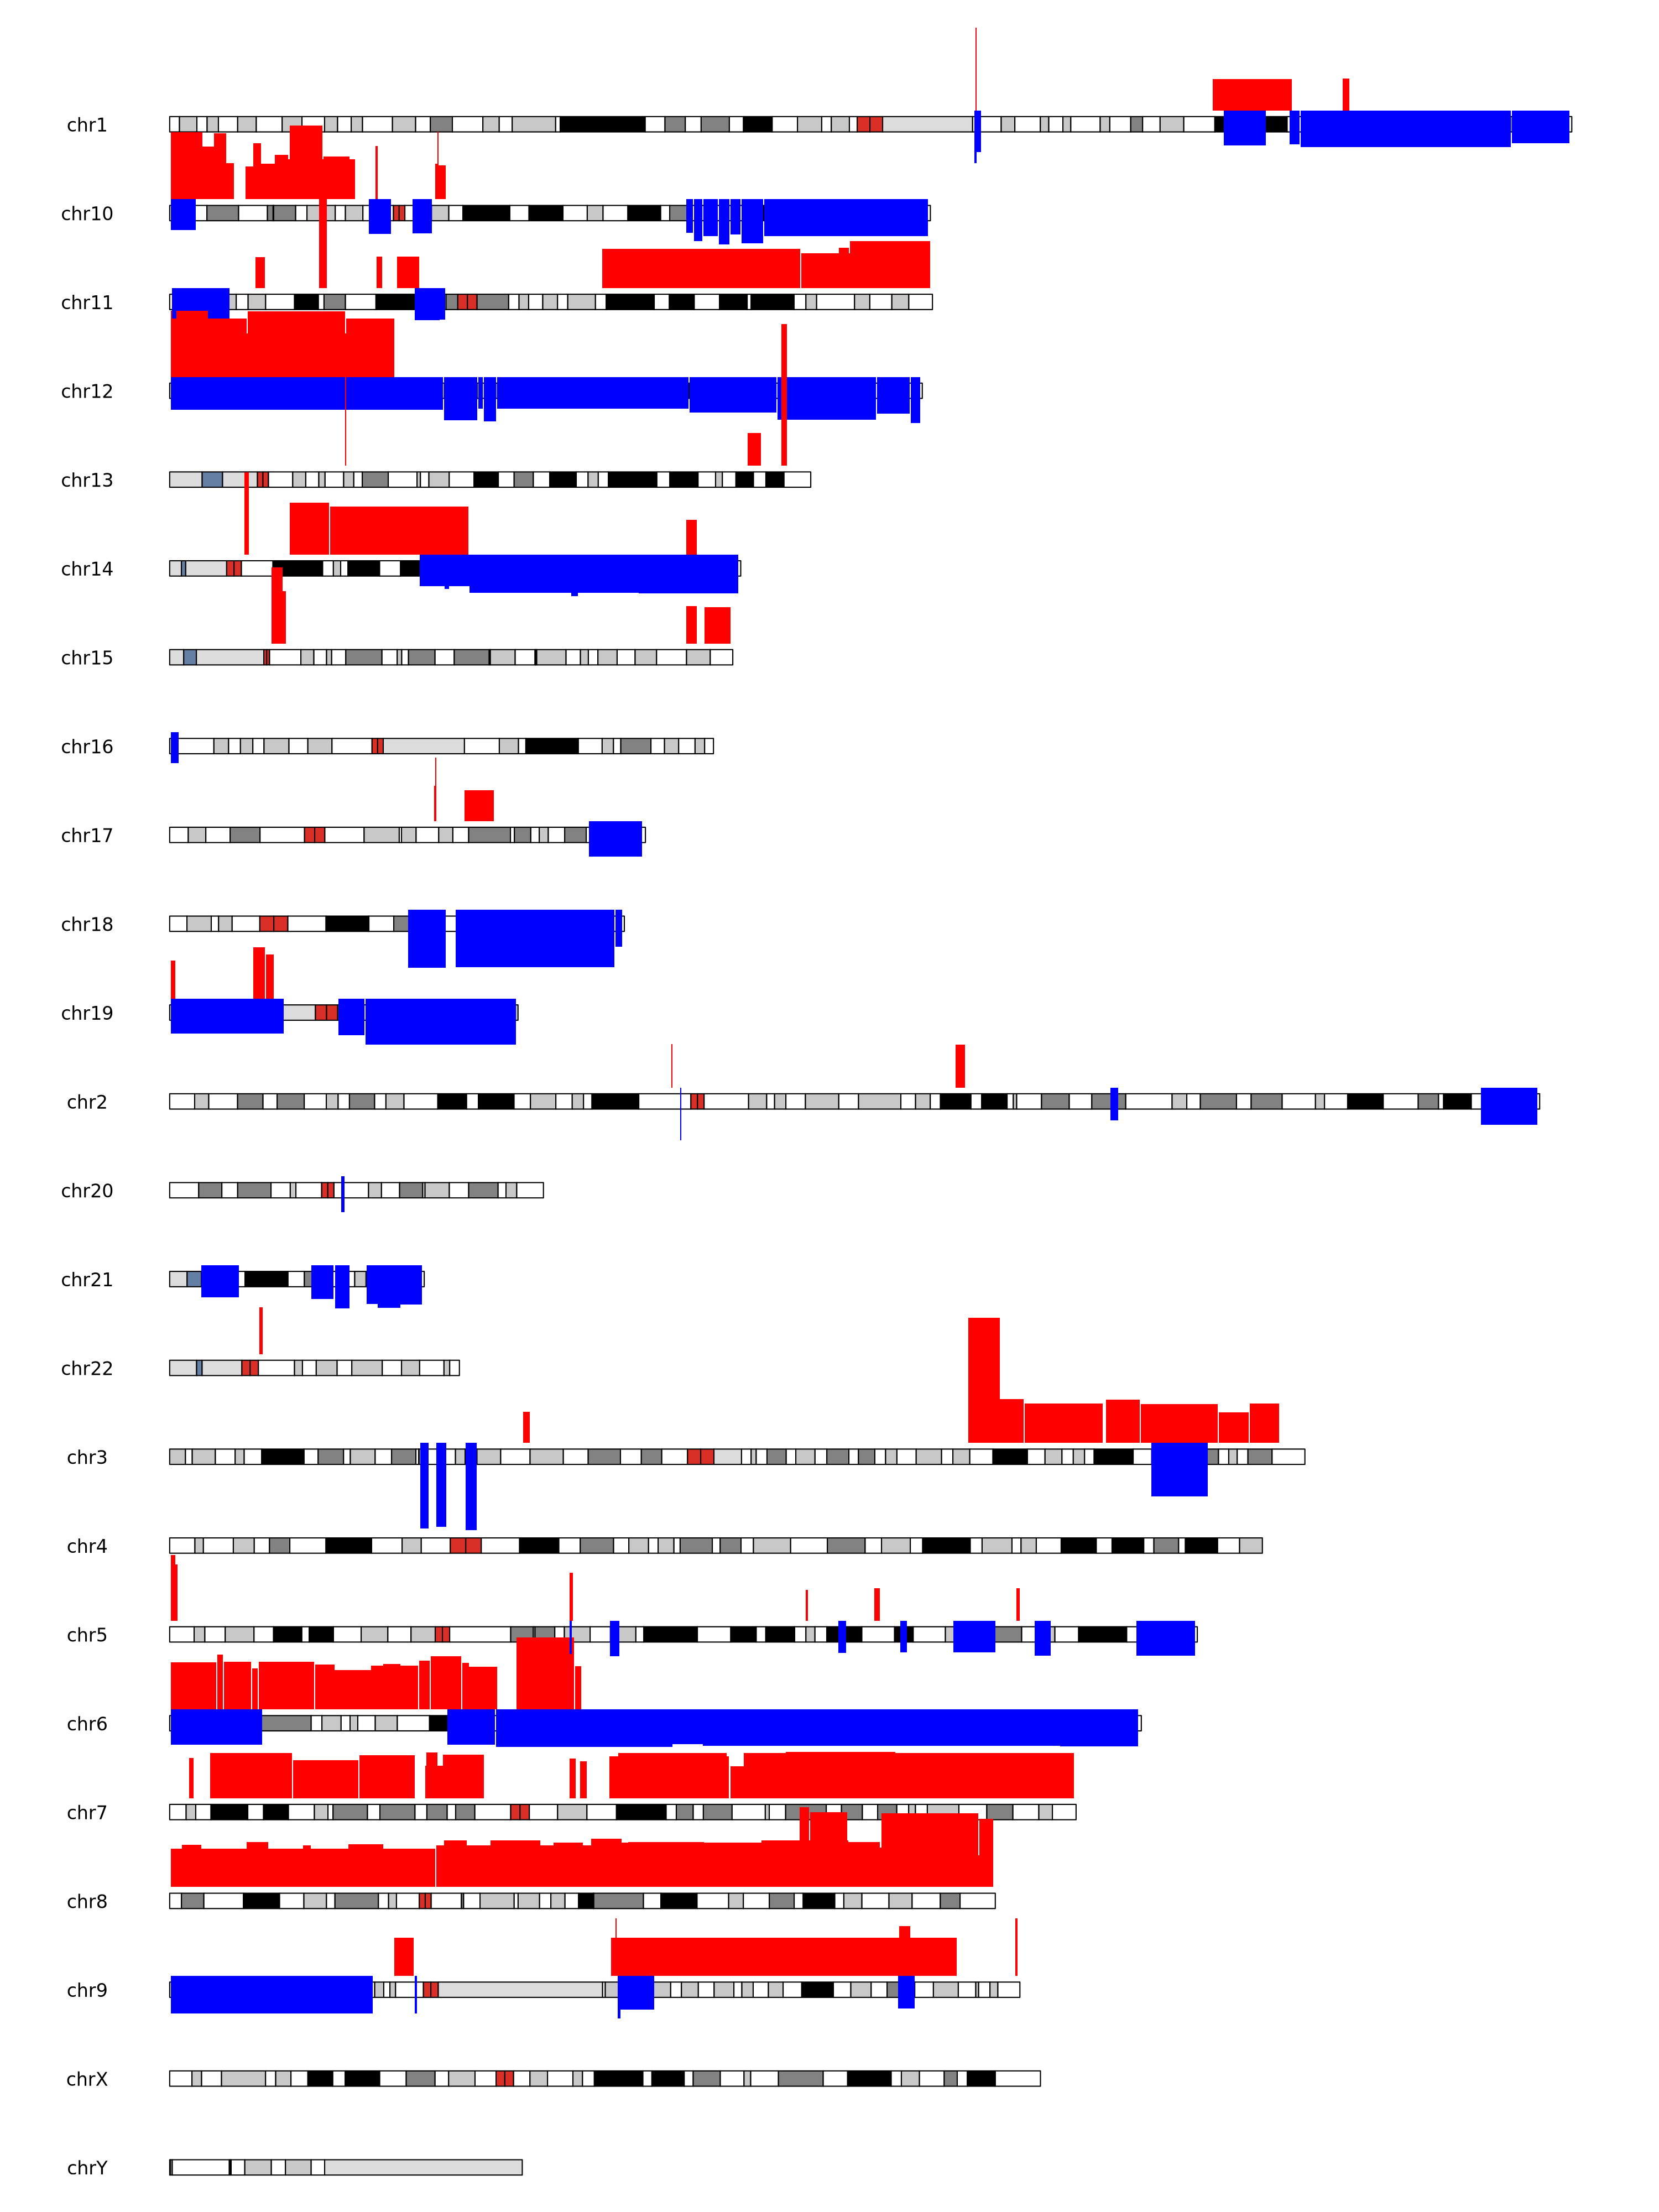

In [44]:
# Filter out "Neutral"
cnv_data_filtered <- subset(df_cnv, Gain_Loss != "Neutral")

# Create GRanges object
cnv_gr <- GRanges(
  seqnames = cnv_data_filtered$chrom,
  ranges = IRanges(start = cnv_data_filtered$loc.start, end = cnv_data_filtered$loc.end),
  Gain_Loss = cnv_data_filtered$Gain_Loss,
  seg.mean = cnv_data_filtered$seg.mean
)

# Set y0 and y1 for plotting
y0 <- rep(0, length(cnv_gr))
y1 <- cnv_gr$seg.mean

options(repr.plot.width = 15, repr.plot.height = 20, repr.plot.res = 200)

kp <- plotKaryotype(genome = custom_genome_gr, cytobands = cytobands)

# Color by Gain/Loss
col_vector <- ifelse(cnv_gr$Gain_Loss == "Loss", "blue", "red")

# Plot CNV segments
kpRect(kp,
       data = cnv_gr,
       y0 = y0,
       y1 = y1,
       col = col_vector,
       border = NA)

# Add title
kpTitle(kp, "Copy Number Gains and Losses")

In [45]:
head(cnv_gr)

GRanges object with 6 ranges and 2 metadata columns:
      seqnames              ranges strand |   Gain_Loss  seg.mean
         <Rle>           <IRanges>  <Rle> | <character> <numeric>
  [1]     chr1 142707663-142907814      * |        Gain    1.3533
  [2]    chr19   52291008-59303188      * |        Loss   -0.6721
  [3]     chr2   90436160-90636240      * |        Loss   -0.8553
  [4]     chr5   70817700-71217800      * |        Gain    0.5409
  [5]     chr9   79009085-79209108      * |        Gain    0.8613
  [6]    chr10   91507395-92708805      * |        Loss   -0.5434
  -------
  seqinfo: 21 sequences from an unspecified genome; no seqlengths